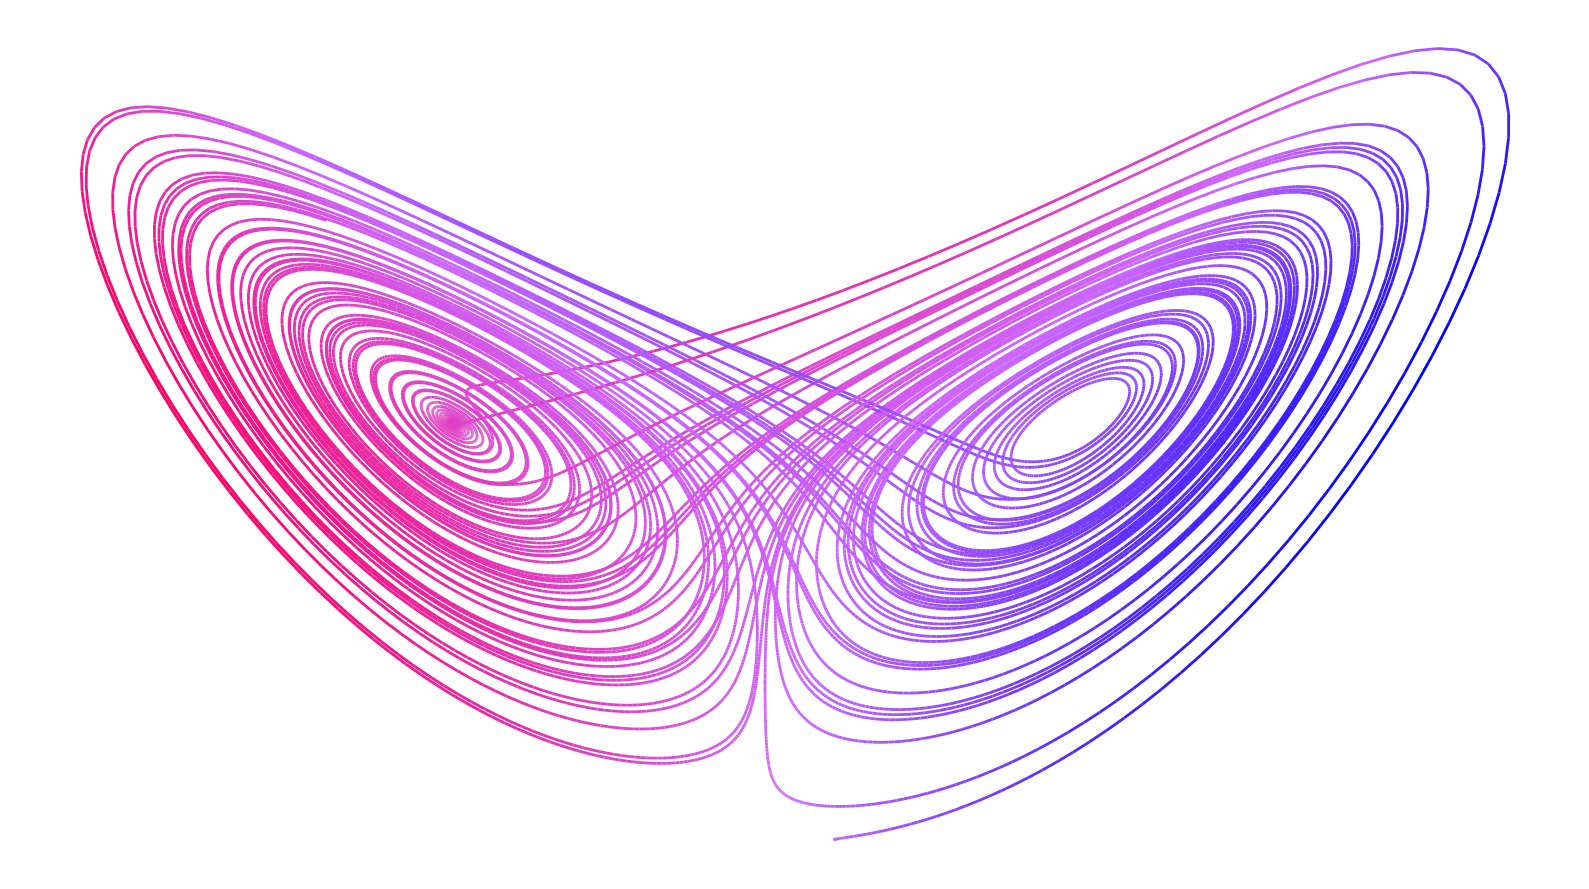

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.colors as mcolors

# Lorenz attractor implemented in Python
# Implementation inspired by: 
# https://medium.com/@alexroz/how-to-plot-chaos-butterfly-effect-in-python-862c0cb621a4

# ------------------------------
# Lorenz attractor class
# ------------------------------
class Attractor:
    def __init__(self, X=1, Y=1, Z=1, sigma=10, rho=28, beta=8/3):
        self.x = X
        self.y = Y
        self.z = Z
        self.sigma = sigma
        self.rho = rho
        self.beta = beta

    def step(self, dt=0.005):
        dx = self.sigma * (self.y - self.x)
        dy = self.x * (self.rho - self.z) - self.y
        dz = self.x * self.y - self.beta * self.z

        self.x += dx * dt
        self.y += dy * dt
        self.z += dz * dt

# ------------------------------
# Generate trajectory
# ------------------------------
butterfly = Attractor(2,1,1)
N = 15000
x, y, z = [], [], []

for _ in range(N):
    x.append(butterfly.x)
    y.append(butterfly.y)
    z.append(butterfly.z)
    butterfly.step()

x = np.array(x)
y = np.array(y)
z = np.array(z)

# ------------------------------
# 2D plot with color by y
# ------------------------------
points = np.array([x, z]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

colors = ["#ff0066", "#cc66ff", "#0000ff"]  # light pink → light purple → light sky blue
cmap = mcolors.LinearSegmentedColormap.from_list("pastel_ppb", colors)
lc = LineCollection(segments, cmap=cmap)
lc.set_array(y)
lc.set_linewidth(2)

fig, ax = plt.subplots(figsize=(16,9))
ax.add_collection(lc)
ax.autoscale_view()
ax.spines[['right', 'top', 'bottom', 'left']].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('Lorenz_2D.png', dpi=300)
plt.show()

# ------------------------------
# 3D interactive plot with Plotly
# ------------------------------
plotly_template = pio.templates["plotly_dark"]

# Use time index for gradient
time = np.arange(len(x))

# Split trajectory into short segments
segments = []
colors = []
for i in range(len(x)-1):
    segments.append((x[i:i+2], y[i:i+2], z[i:i+2]))
    colors.append(time[i])  # color varies along trajectory

fig = go.Figure()